# Imports

In [32]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", message=".*anndata.*", category=FutureWarning)
plt.rcParams["font.family"] = "Arial"
# - dirs 
from ciim.src.common import base_dir, plots_dir, datasets_all, aging_clock_train_datasets, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types, \
        par_simulation

from ciim.src.tf_activity.helper import retrieve_sig_stats, get_consensus_net
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from ciim.src.insilico_perturbation.plots import plot_age_acceleration, heatplot_perturbation_effect
from ciim.src.utils.util import get_genesets, get_essential_hallmark
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_single_perturbation, summarize_pathway_scores


n_jobs = 20


cell_types = ['CD4T', 'CD8T'] #['CD4T', 'CD8T',  'NK', 'MONO']
opengenes_pathways = get_genesets('opengenes')
essential_genes = get_genesets('essential')
essential_hallmark = get_essential_hallmark()
gene_score_shift_col = 'gene_score_shift_log2fc'

par = par_simulation

# Pathway genes perturbation

In [10]:
for key in essential_hallmark.keys():
    if 'mtor' in key.lower():
        print(key)

PI3K/AKT/mTOR  Signaling
mTORC1 Signaling


In [11]:
cell_type = 'CD8T'
target_pathways = ['mTORC1 Signaling']

tf_selection_type = 'top_tfs' #  'top_tfs', 'top_enriched_tfs'

pathways = get_genesets()
pathway_genes = [
    gene
    for tp in target_pathways
    for gene in pathways[tp]
]
grn = get_consensus_net(cell_type=cell_type)
grn_pathway = grn[grn['target'].isin(pathway_genes)]

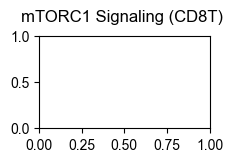

In [12]:
from ciim.src.tf_activity.plots import plot_feature_values_all_datasets, plot_feature_values_per_datasets
for case_term in target_pathways:
    datasets = datasets = [d for d in datasets_all if d != 'data12']

    fig, ax = plt.subplots(1, 1, figsize=(2.2, 1.2))

    plot_feature_values_all_datasets(cell_type, feature=case_term, feature_type='gene_score', type='bulk', datasets=datasets, show_cbar=True, ax=ax,
                                        show_ylabels=True)


    plt.suptitle(f'{case_term} ({cell_type})', y=1.1)
    plt.savefig(f'{plots_dir}/{case_term}_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)

In [13]:
if False:
    from ciim.src.utils.util import get_genesets
    terms = []
    for term in pathways.keys():
        if ('mtor' in term.lower()) | ('ampk' in term.lower()):
            print(term, len(pathways[term]))
            terms.append(term)
    pathways = {k: pathways[k] for k in terms}

## Top regulators of the pathway genes: overall regualtors

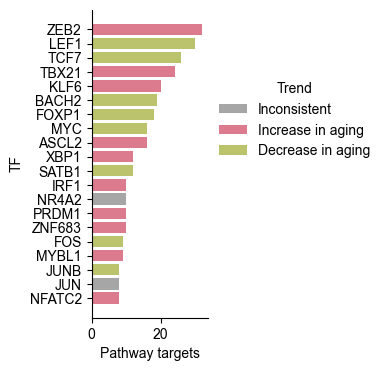

In [14]:
tf_counts = grn_pathway['source'].value_counts().sort_values(ascending=False)
tf_counts_top = tf_counts.head(20).reset_index()  # Limit to top 20 TFs for clarity

stats_aging = retrieve_sig_stats(cell_type=cell_type).drop_duplicates(subset=['cell_type', 'tf', 'trend']).reset_index(drop=True)[['tf', 'trend']]

tf_counts_top = tf_counts_top.merge(stats_aging, left_on='source', right_on='tf', how='left').fillna('Inconsistent')
tf_counts_top['trend'] = pd.Categorical(
    tf_counts_top['trend'],
    categories=palette_trend.keys(),
    ordered=True
)
# Plot

fig, ax = plt.subplots(figsize=(1.5, 4))
tf_counts_top = tf_counts_top.sort_values('count', ascending=True)

sns.barplot(
        data=tf_counts_top,
        y='source',
        x='count',
        hue='trend',
        color=colors_blind[2],
        palette=palette_trend,
        edgecolor='black',
        linewidth=0.01,  
        alpha=.7,
        ci=None,
        ax=ax
    )
ax.margins(y=.05)
# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.legend(loc=[1.05, 0.5], title='Trend',frameon=False, markerscale=1)
plt.savefig(f'{plots_dir}/tf_counts_pathway.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'{}', fontsize=8)

## To regulators of the given pathway genes: enriched regulators

In [15]:
from scipy.stats import fisher_exact

# All TFs in the GRN
all_tfs = grn['source'].unique()

# Set of all targets and pathway targets
all_targets = set(grn['target'])
pathway_targets = set(pathway_genes) & all_targets  # keep only known targets

results = []

for tf in all_tfs:
    tf_targets = set(grn.loc[grn['source'] == tf, 'target'])

    a = len(tf_targets & pathway_targets)                     # TF → pathway target
    b = len(tf_targets - pathway_targets)                     # TF → non-pathway target
    c = len(pathway_targets - tf_targets)                     # other TFs → pathway target
    d = len((all_targets - pathway_targets) - (tf_targets - pathway_targets))  # other TFs → non-pathway

    # Skip TFs with no target or zero counts to avoid math errors
    if (a + b + c + d) == 0 or (a + b == 0) or (c + d == 0):
        continue

    # Fisher's exact test
    oddsratio, pval = fisher_exact([[a, b], [c, d]], alternative='greater')  # test for over-representation

    results.append({
        'TF': tf,
        'n_pathway_targets': a,
        'n_total_targets': a + b,
        'odds_ratio': oddsratio,
        'pval': pval
    })

# Convert to DataFrame
df_enrich = pd.DataFrame(results)

# Adjust for multiple testing (optional)
from statsmodels.stats.multitest import multipletests
df_enrich['pval_adj'] = multipletests(df_enrich['pval'], method='fdr_bh')[1]

# Sort by significance
df_enrich = df_enrich[df_enrich['pval_adj'] < 0.05]
df_enrich = df_enrich.sort_values('pval')
df_enrich

,TF,n_pathway_targets,n_total_targets,odds_ratio,pval,pval_adj
83,NR4A2,10,81,7.21275,0.00001,0.001753


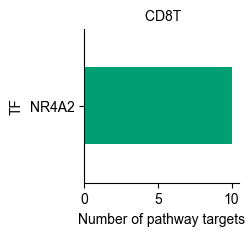

In [16]:
df = df_enrich.sort_values('pval_adj', ascending=True).head(30)
df = df[['TF', 'n_pathway_targets']].set_index('TF')
fig, ax = plt.subplots(figsize=(2, max(2, len(df) * 0.2)))
df.plot(kind='barh', ax=ax, color=colors_blind[2], edgecolor=None)

# Aesthetics
ax.invert_yaxis()  # Largest count at the top
ax.set_xlabel('Number of pathway targets')
ax.set_ylabel('TF')
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.margins(y=0.1)  # Add margins for better visibility
ax.set_title(f' {cell_type}', weight='bold', fontsize=10)
ax.get_legend().remove()  # Remove legend if not needed

## Run perturbation simulation for different selection of TFs

In [17]:
top_tfs_counts = [2, 5, 7, 10, 15, 20, 25, 50]
if tf_selection_type == 'top_tfs': # general regulators
    tfs_list = tf_counts.index.tolist()
elif tf_selection_type == 'top_enriched_tfs':
    tfs_list = df_enrich.sort_values('pval_adj', ascending=True)['TF'].tolist()
else:
    raise ValueError(f'Unknown tf_selection_type: {tf_selection_type}')

In [18]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
from collections import defaultdict

datasets = datasets_all

results = defaultdict(list)

raw_rr_store = []
for n in top_tfs_counts:
    # - get top N TFs regulating the pathway
    tfs = tfs_list[:n]

    par[tfs] = tfs
    raw_rr = wrapper_in_silico_perturbation(par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets_all)
    raw_rr['n'] = n
    raw_rr_store.append(raw_rr)

raw_rr = pd.concat(raw_rr_store).reset_index()

TypeError: unhashable type: 'list'

## Plot age shift and gene score shift per donor

In [15]:
if False: # donor level plot
    from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
    datasets = raw_rr['dataset'].unique()
    n_datasets = len(datasets)
    # for n in raw_rr['n'].unique():
    for n in [10]:
        rr = raw_rr[raw_rr['n'] == n].copy()
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            rr_sub = rr[(rr['cell_type'] == cell_type) & (rr['dataset'] == dataset)].copy()
            df = rr_sub['age_shift']
            df['donor_age'] = rr_sub['donor_age']
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"{cell_type}: {n}", y=1.25, fontsize=12, fontweight='bold')

## Plot the effect of perturbation on aging pathways 

In [16]:
# - summary of pathway gene score shift
score_shift_summary = summarize_pathway_scores(raw_rr)
# - subset to aging tfs
if False: 
    stats_sig = retrieve_sig_stats(feature_type='gene_score').drop_duplicates(subset=['cell_type', 'pathway'])[['pathway', 'cell_type', 'slope']].rename(columns={'slope': 'spearman_slope'})
    # stats_sig = stats_sig[stats_sig['spearman_slope'].abs() > 0.4] # # filter to pathways with significant aging slope -> move this to helper function
    score_shift_summary = score_shift_summary.merge(stats_sig, on=['cell_type', 'pathway'], how='inner')
    print(score_shift_summary.shape)
# print(df_pathway_score_shift_summary['pathway'].value_counts())
if False:
    # - calculate the natural aging slope
    from ciim.src.insilico_perturbation.helper import compute_slopes
    from ciim.src.utils.util.helper import retrieve_feature_data
    slope_store = []
    for dataset in datasets:
        # adata = retrieve_feature_data(cell_type=cell_type, dataset=dataset)
        adata = ad.read_h5ad(f"{save_dir}/gene_expression_smoothed/{dataset}_{cell_type}_bulk.h5ad")
        slope = compute_slopes(adata, feature_type='gene_score')
        slope.index.name = 'pathway'
        slope = slope.reset_index()
        slope['dataset'] = dataset   
        slope_store.append(slope)
    df_slope = pd.concat(slope_store).reset_index(drop=True).rename(columns={'slope': 'aging_slope'})

    # - calculate 10 years slope
    df_slope['aging_slope'] = df_slope['aging_slope'] * 10  # convert to 10 years slope

    score_shift_summary = score_shift_summary.merge(df_slope, on=['dataset', 'pathway'], how='left')

    score_shift_summary['perturbation_effect'] = score_shift_summary['gene_score_shift'] / score_shift_summary['aging_slope']
else:
    score_shift_summary.head()

## Plot age shift and the target pathway's gene score shift for different TF selection

In [17]:
target_pathway = target_pathways[0]
target_pathway

'MTORC1 SIGNALING'

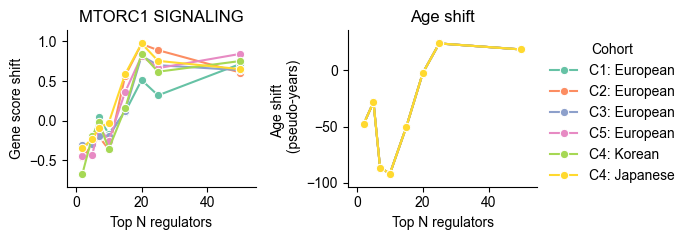

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

age_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])['age_shift'].mean()['age_shift']['age_shift'].reset_index()
age_shift_summary['dataset'] = pd.Categorical(age_shift_summary['dataset'], categories=datasets_all, ordered=True)
age_shift_summary['dataset'] = age_shift_summary['dataset'].map(surrogate_names)

gene_score_shift_summary = raw_rr.groupby(['cell_type', 'dataset', 'n'])[target_pathway].mean()[target_pathway]['gene_score_shift'].reset_index()

gene_score_shift_summary['dataset'] = pd.Categorical(gene_score_shift_summary['dataset'], categories=datasets_all, ordered=True)
gene_score_shift_summary['dataset'] = gene_score_shift_summary['dataset'].map(surrogate_names)


fig, axes = plt.subplots(1, 2, figsize=(7, 2.5))

ax = axes[0]

sns.lineplot(data=gene_score_shift_summary, x='n', y='gene_score_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title(f'{target_pathway}')
ax.set_ylabel('Gene score shift')
ax.set_xlabel('Top N regulators')
# ax.set_xticks(top_tfs_counts)
ax.margins(x=0.1, y=0.1)
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.get_legend().remove()

ax = axes[1]
sns.lineplot(data=age_shift_summary, x='n', y='age_shift', hue='dataset', marker='o', ax=ax, palette=palette_datasets_pretty)
ax.set_title('Age shift')
ax.set_ylabel('Age shift \n (pseudo-years)')
ax.set_xlabel('Top N regulators')
# ax.set_xticks(top_tfs_counts)
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines

ax.margins(x=0.1, y=0.1)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Cohort', frameon=False)
# plt.suptitle(f'{cell_type}', fontsize=12, weight='bold')
plt.tight_layout()
plt.savefig(f'{plots_dir}/{target_pathway}_{cell_type}_gene_score_shift.png', bbox_inches='tight', dpi=300, transparent=True)

### Per top n regulators perturbation: average over datasets

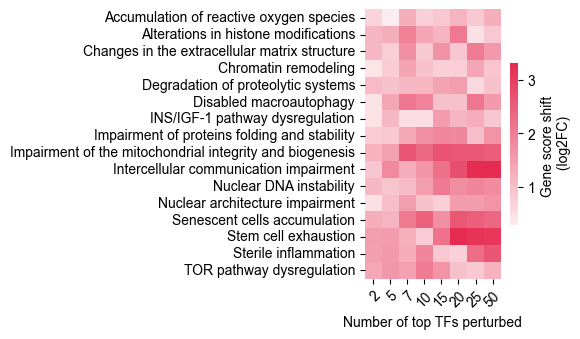

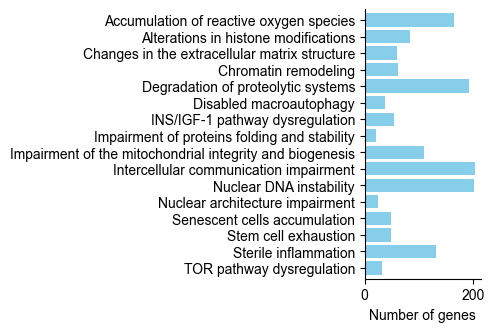

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


def barplot_pathway_counts(df_terms, ax):
    df_terms.plot(kind='barh', 
                  color='skyblue', 
                  width=0.8,
                  edgecolor=None, 
                  ax=ax, 
                  legend=False)
    ax.set_xlabel('Number of genes')
    ax.set_ylabel('')
    ax.set_title('')
    ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines

# --- Prepare data ---

df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(opengenes_pathways.keys())]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='n', values=gene_score_shift_col)

opengenes_pathways_n = {key: len(values) for key, values in opengenes_pathways.items()}
opengenes_terms_n = {k: v for k, v in opengenes_terms_n.items() if k in pivot_df.index}
df_terms = pd.DataFrame.from_dict(opengenes_terms_n, orient='index', columns=['count'])
df_terms = df_terms.loc[pivot_df.index]  # ensure order consistency
df_terms = df_terms.iloc[::-1]
# --- Plot side by side ---
fig, ax1 = plt.subplots(1, 1, figsize=(2.2, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1)
fig, ax2 = plt.subplots(1, 1, figsize=(1.5, max(3.5, len(pivot_df) * 0.18)))
barplot_pathway_counts(df_terms, ax2)
# ax2.set_yticklabels([])
plt.savefig(f'{plots_dir}/opengenes_gene_score_shift.png', bbox_inches='tight', dpi=300, transparent=True)
plt.show()

Text(0.5, 9.222222222222216, '')

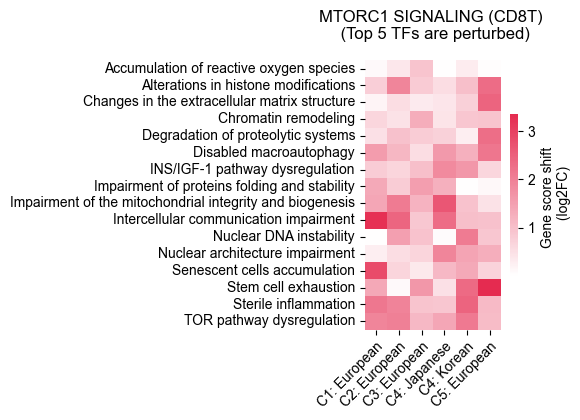

In [20]:
n = 5
df = df_summary_opengenes[df_summary_opengenes['n']==n].copy()
df['dataset'] = df['dataset'].apply(lambda x: surrogate_names[x] if x in surrogate_names else x)

pivot_df = df.pivot_table(index='pathway', columns='dataset', values=gene_score_shift_col)

fig, ax = plt.subplots(figsize=(2.2, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax=ax)

plt.title(f'{target_pathway} ({cell_type}) \n (Top {n} TFs are perturbed)', pad=15, fontsize=12, fontweight='bold')
plt.xlabel('')

# Identify novel rejuvinating TFs

In [20]:
cell_type = 'CD8T'
net = get_consensus_net(cell_type=cell_type)

## TFs risk scores

In [6]:
TF_all = net['source'].unique().tolist()

In [35]:
from scipy.stats import fisher_exact, entropy
from statsmodels.stats.multitest import multipletests
import pandas as pd

# -- Flatten gene sets --
genes_opengenes = set().union(*opengenes_pathways.values())
genes_hallmark = set().union(*essential_hallmark.values()) if isinstance(essential_hallmark, dict) else set(essential_hallmark)

# -- Setup main tracking variables --
results = []
per_pathway_data = {}  # (category, term): list of values per TF

all_targets = set(net['target'])
all_essentials = set(*essential_genes.values())
all_opengenes = genes_opengenes
all_hallmark = genes_hallmark

# -- Create space for detailed pathway overlap counts --
all_term_sets = {
    **{('OpenGenes', k): set(v) for k, v in opengenes_pathways.items()},
    **{('Essential hallmark', k): set(v) for k, v in essential_hallmark.items()}
}
for (category, term), geneset in all_term_sets.items():
    per_pathway_data[(category, term, 'n_overlap')] = []
    per_pathway_data[(category, term, 'overlap_ratio')] = []

# -- Main loop per TF --
for tf, group in net.groupby('source'):
    tf_targets = set(group['target'])
    n_targets = len(tf_targets)

    # Global overlaps
    n_essential = len(tf_targets & all_essentials)
    n_opengenes = len(tf_targets & all_opengenes)
    n_hallmark = len(tf_targets & all_hallmark)

    # Fisher test
    a, b = n_essential, n_targets - n_essential
    c, d = len(all_essentials - tf_targets), len(all_targets - all_essentials - tf_targets)
    odds, pval = fisher_exact([[a, b], [c, d]], alternative='greater')

    # Entropy of TF's target distribution
    tf_entropy = entropy(pd.Series(group['target']).value_counts(normalize=True))

    results.append({
        'tf': tf,
        'n_targets': n_targets,
        'n_essential': n_essential,
        'n_opengenes': n_opengenes,
        'n_hallmark': n_hallmark,
        'entropy': tf_entropy,
        'fisher_pval_essential': pval
    })

    # -- Per pathway overlaps --
    for (category, term), geneset in all_term_sets.items():
        overlap = tf_targets & geneset
        per_pathway_data[(category, term, 'n_overlap')].append(len(overlap))
        per_pathway_data[(category, term, 'overlap_ratio')].append(len(overlap) / len(geneset) if len(geneset) > 0 else 0)

# -- Compile main TF-level df --
df = pd.DataFrame(results)
df['fisher_fdr'] = multipletests(df['fisher_pval_essential'], method='fdr_bh')[1]

# Normalize global metrics
for col in ['n_essential', 'n_opengenes', 'n_hallmark', 'entropy']:
    df[f'{col}_norm'] = df[col] / df[col].max()

# Composite risk score
df['risk_score'] = df[['n_essential_norm', 'n_opengenes_norm', 'n_hallmark_norm', 'entropy_norm']].mean(axis=1)

# -- Per pathway detailed df with MultiIndex columns --
multi_columns = pd.MultiIndex.from_tuples(per_pathway_data.keys(), names=['Category', 'Term', 'Metric'])
df_per_pathway = pd.DataFrame(per_pathway_data, index=df['tf'])
df_per_pathway.columns = multi_columns

# -- Final full dataframe with everything --
df_full = pd.concat([df.set_index('tf'), df_per_pathway], axis=1)

df_full.head()

,n_targets,n_essential,n_opengenes,n_hallmark,entropy,fisher_pval_essential,fisher_fdr,n_essential_norm,n_opengenes_norm,n_hallmark_norm,...,"(Essential hallmark, E2F Targets, n_overlap)","(Essential hallmark, E2F Targets, overlap_ratio)","(Essential hallmark, Myc Targets V1, n_overlap)","(Essential hallmark, Myc Targets V1, overlap_ratio)","(Essential hallmark, Myc Targets V2, n_overlap)","(Essential hallmark, Myc Targets V2, overlap_ratio)","(Essential hallmark, Oxidative Phosphorylation, n_overlap)","(Essential hallmark, Oxidative Phosphorylation, overlap_ratio)","(Essential hallmark, p53 Pathway, n_overlap)","(Essential hallmark, p53 Pathway, overlap_ratio)"
tf,,,,,,,,,,,,,,,,,,,,,
AEBP1,150,53,12,23,5.010635,0.995207,1.000000,0.242009,0.088235,0.116162,...,2,0.010,13,0.065,2,0.034483,1,0.005,6,0.030
AKNA,306,80,31,39,5.723585,1.000000,1.000000,0.365297,0.227941,0.196970,...,1,0.005,14,0.070,2,0.034483,3,0.015,9,0.045
ARID5B,212,68,23,31,5.356586,0.999979,1.000000,0.310502,0.169118,0.156566,...,3,0.015,15,0.075,3,0.051724,1,0.005,8,0.040
ASCL2,644,125,46,81,6.467699,1.000000,1.000000,0.570776,0.338235,0.409091,...,3,0.015,23,0.115,2,0.034483,10,0.050,20,0.100
ATF6B,6,6,0,1,1.791759,0.008479,0.081666,0.027397,0.000000,0.005051,...,0,0.000,0,0.000,0,0.000000,0,0.000,1,0.005


## Pre-filter TFs

In [36]:
def filter_tfs_by_essentialgenes(net):
    from scipy.stats import fisher_exact

    results = []

    all_targets = set(net['target'])
    all_essentials = set(*essential_genes.values())
    all_non_essentials = all_targets - all_essentials

    for tf, group in net.groupby('source'):
        tf_targets = set(group['target'])
        a = len(tf_targets & all_essentials)
        b = len(tf_targets & all_non_essentials)
        c = len(all_essentials - tf_targets)
        d = len(all_non_essentials - tf_targets)

        table = [[a, b], [c, d]]
        odds, pval = fisher_exact(table, alternative='less')  # or 'less' for depletion
        results.append({'tf': tf, 'odds_ratio': odds, 'pval': pval, 'n_essential_targets': a, 'n_total_targets': len(tf_targets)})

    fisher_df = pd.DataFrame(results)
    from statsmodels.stats.multitest import multipletests
    fisher_df['fdr'] = multipletests(fisher_df['pval'], method='fdr_bh')[1]
    fisher_df = fisher_df[fisher_df['fdr'] < 0.05]
    passed_tfs = fisher_df['tf'].unique()
    return net[net['source'].isin(passed_tfs)]
# - filter one: select tfs that are not central: buttom .2 quantile
quantile_threshold = 0.8  # Bottom qnatile
centrality = net.groupby('source')['target'].count().reset_index()
centrality = centrality.rename(columns={'target': 'n_targets'})
low_central_tfs = centrality[centrality['n_targets'] <= centrality['n_targets'].quantile(quantile_threshold)]['source']
net_f = net[net['source'].isin(low_central_tfs)]

# - filter two: select tfs that are regulatig essential genes
net_f = filter_tfs_by_essentialgenes(net_f)
net_f['source'].nunique(), net_f['target'].nunique(), net_f.shape


(105, 627, (6582, 3))

In [37]:
TF_all_prefiltered = net_f['source'].unique().tolist()
len(TF_all_prefiltered)

105

### Check the single factor effects

In [38]:
perturb_rr_mean = pd.read_csv(f"{save_dir}/perturbation/single_aging_tf_age_shift_mean.csv")
perturb_rr_mean = perturb_rr_mean[(perturb_rr_mean['cell_type']== cell_type) & (perturb_rr_mean['tf'].isin(TF_all_prefiltered))]

score_shift_summary = pd.read_csv(f"{save_dir}/perturbation/single_aging_tf_pathway_score_shift.csv")
score_shift_summary = score_shift_summary[(score_shift_summary['cell_type'] == cell_type) & (score_shift_summary['tf'].isin(TF_all_prefiltered))]

Text(0.5, 1.0, 'Essential genes (DepMap)')

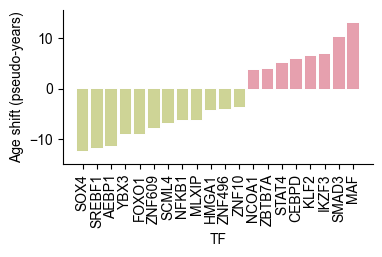

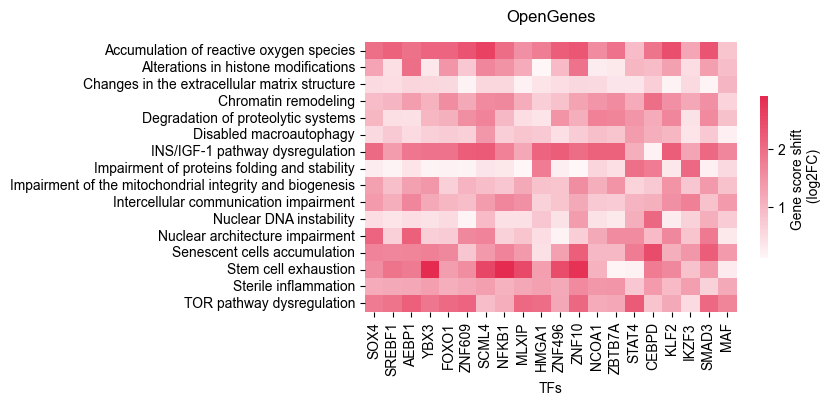

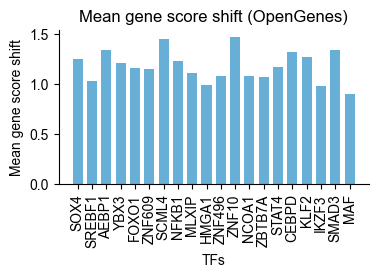

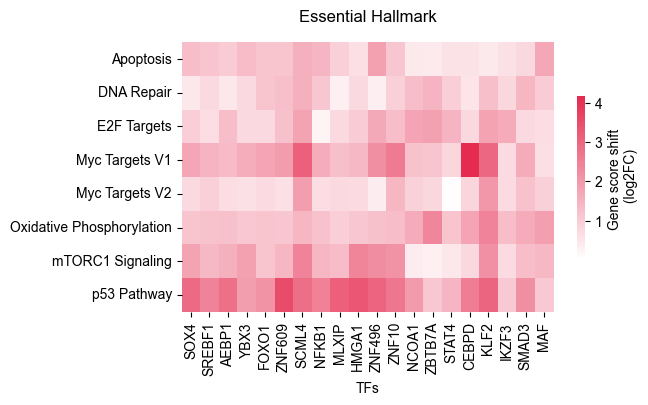

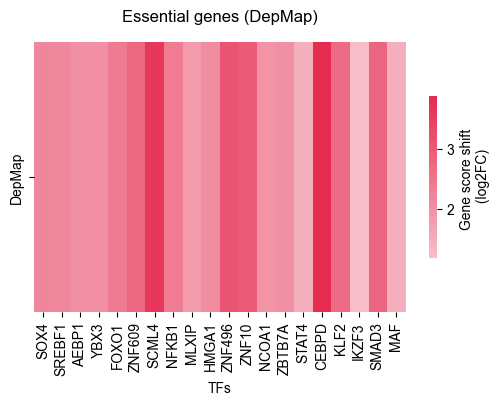

In [39]:
from ciim.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation

value_col= 'mean_diff' #'mean_diff' #'z_score'#'signed_neg_log10_pval'
features = None
top_n=20
# - plot age shift 
aa, ordered_top_tfs = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_mean, 
                                        value_col=value_col, 
                                        top_n=top_n,
                                        figsize=(4, 2))
plt.ylabel('Age shift (pseudo-years)')
plt.title(f"", pad=15, weight='bold')

# - plot gene score shift for opengenes
df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(opengenes_pathways)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='tf', values=gene_score_shift_col)
pivot_df = pivot_df[ordered_top_tfs]  # reorder columns based on ordered_top_tfs

fig, ax1 = plt.subplots(1, 1, figsize=(6, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1, gene_score_shift_col)
ax1.set_xlabel('TFs')
bb = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='center')
plt.title(f"OpenGenes", pad=15, weight='bold')

# - mean score shift
mean_pivot_df = pivot_df.mean(axis=0).reset_index(name='mean_value')
fig, ax = plt.subplots(figsize=(4, 2))
barplot = sns.barplot(
        data=mean_pivot_df,
        y='mean_value',
        x='tf',
        ax=ax,
        width=0.7,
        # palette='viridis'
        color=colors_blind[1],
    )
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.set_ylabel('Mean gene score shift')
ax.set_xlabel('TFs')
ax.margins(x=0.05, y=0.05)
bb = ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
plt.title('Mean gene score shift (OpenGenes)')

# - plot gene score shift for essential hallmark
df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(essential_hallmark)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='tf', values=gene_score_shift_col)
pivot_df = pivot_df[ordered_top_tfs]  # reorder columns based on ordered_top_tfs

fig, ax1 = plt.subplots(1, 1, figsize=(6, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1, gene_score_shift_col)
ax1.set_xlabel('TFs')
bb = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='center')
plt.title(f"Essential Hallmark", pad=15, weight='bold')

# - plot gene score shift for essential genes
df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(essential_genes)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='tf', values=gene_score_shift_col)
pivot_df = pivot_df[ordered_top_tfs]  # reorder columns based on ordered_top_tfs

fig, ax1 = plt.subplots(1, 1, figsize=(6, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1, gene_score_shift_col)
ax1.set_xlabel('TFs')
bb = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='center')
plt.title(f"Essential genes (DepMap)", pad=15, weight='bold')



In [ ]:
aaa

## Look for multi-factor rejuvinating TFs

In [2]:
# - run the analysis
# np.savetxt(f"{save_dir}/candidate_tfs.txt", ordered_top_tfs, fmt="%s")
!bash ../scripts/run_insilico_perturbation.sh

-12.32888626274243  best_age_shift inf detr_score 1.1773982240707166
-11.843065777081625  best_age_shift inf detr_score 1.1338387643395214
-11.348722453621754  best_age_shift inf detr_score 1.1580612581446803
-9.061469180592104  best_age_shift inf detr_score 1.1453789121050437
-9.011139165240484  best_age_shift inf detr_score 1.0944490190444969
-7.7935146821862835  best_age_shift inf detr_score 1.2109987583375004
-6.849369328988155  best_age_shift inf detr_score 1.3693127716643851
-6.290213666034207  best_age_shift inf detr_score 1.2251391452549871
-6.282294254593879  best_age_shift inf detr_score 1.1396013141213968
-4.289040312676944  best_age_shift inf detr_score 1.1141153308397898
-3.9892586645211847  best_age_shift inf detr_score 1.2351426981612865
-3.7109813337428044  best_age_shift inf detr_score 1.164404827809538
3.670215814147734  best_age_shift inf detr_score 1.118579884187759
3.8000213239730725  best_age_shift inf detr_score 1.0839174632688002
5.141387069727986  best_age_shif

In [28]:
optimization_rr = pd.read_csv(f"{save_dir}/optimization_results.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/vol/projects/jnourisa//output//optimization_results.csv'

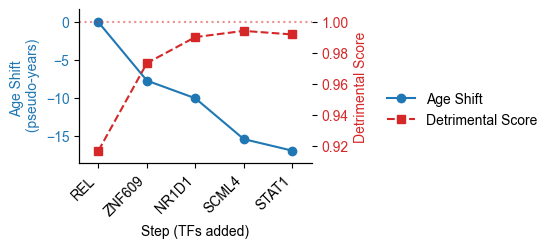

In [ ]:
def plot_greedy_tf_selection(df_results):
    fig, ax1 = plt.subplots(figsize=(3, 2))
    margins = dict(x=0.1, y=0.1)

    # Plot age_shift
    ax1.plot(df_results['step'], df_results['age_shift'], marker='o', color='tab:blue', label='Age Shift')
    ax1.set_xlabel('Step (TFs added)')
    ax1.set_ylabel('Age Shift \n (pseudo-years)', color='tab:blue')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    # Show TFs on x-axis
    ax1.set_xticks(df_results['step'])
    ax1.set_xticklabels(df_results['added_tf'], rotation=45, ha='right')
    

    # Plot detr_score on secondary y-axis
    ax2 = ax1.twinx()
    ax2.plot(df_results['step'], df_results['detr_score'], marker='s', linestyle='--', color='tab:red', label='Detrimental Score')
    ax2.set_ylabel('Detrimental Score', color='tab:red')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    # Legends
    lines_1, labels_1 = ax1.get_legend_handles_labels()
    lines_2, labels_2 = ax2.get_legend_handles_labels()
    ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc=[1.3, .2], frameon=False)

    ax1.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
    ax2.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
    ax1.margins(**margins)
    ax2.margins(**margins)
    
    # Add a title
    # plt.title('Greedy TF Selection: Age Shift vs Detrimental Score', pad=15)
    # plt.tight_layout()
    
plot_greedy_tf_selection(df_results)

In [ ]:
selected_tfs_final = selected_tfs
selected_tfs_final

In [ ]:
features = selected_tfs_final
from ciim.src.tf_activity.plots import plot_features_vs_datasets
bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', 
                            sizes=(90, 100), width=4,
                            margins_ax1={'x': 0.1, 'y': 0.1}, margins_ax2={'x': 0.1, 'y': 0.07})
# plt.suptitle(f"", fontsize=12, weight='bold')
# plt.savefig(f"{plots_dir}/{cell_type}_tf_activity.png", bbox_inches='tight', dpi=300, transparent=True)

## Pathway score shift due to perturbation

In [71]:
# - run again
raw_rr_store = []
tfs = []
for tf in selected_tfs_final:
    tfs = tfs + [tf] 
    # - run
    par[tfs] = tfs
    raw_rr = wrapper_in_silico_perturbation(par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets_all)
    # - post run
    raw_rr['tfs'] = ','.join(tfs)
    raw_rr['added_tf'] = tf
    raw_rr_store.append(raw_rr)
raw_rr = pd.concat(raw_rr_store)

In [72]:
mean_scores = summarize_pathway_scores(raw_rr, cols=['cell_type', 'added_tf'])

In [76]:
mean_scores['added_tf'] = pd.Categorical(
    mean_scores['added_tf'],
    categories=selected_tfs_final,
    ordered=True
)

In [89]:
from ciim.src.insilico_perturbation.plots import plot_pathway_score_shift

NameError: name 'get_opengenes_sets' is not defined

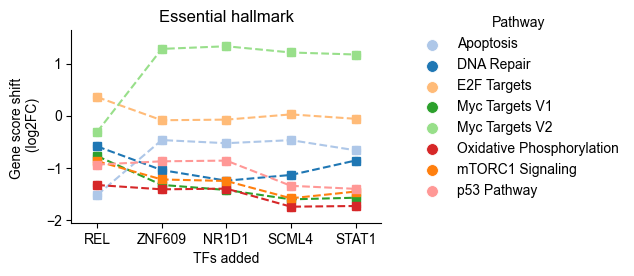

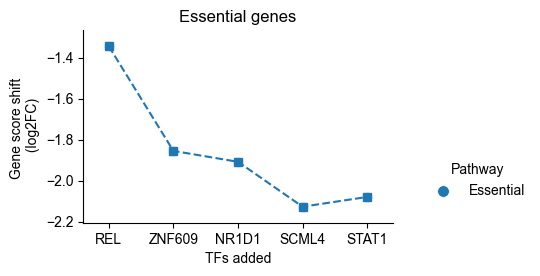

In [94]:
hallmark_terms = list(get_essential_hallmark().keys())
mean_scores_s = mean_scores[mean_scores['pathway'].isin(hallmark_terms)]
plot_pathway_score_shift(mean_scores_s)
plt.title(f'Essential hallmark', fontsize=12, weight='bold')

terms =  list(get_essential_genes().keys())
mean_scores_s = mean_scores[mean_scores['pathway'].isin(terms)]
plot_pathway_score_shift(mean_scores_s)
plt.title(f'Essential genes', fontsize=12, weight='bold')


Text(0.5, 1.0, 'OpenGenes pathways')

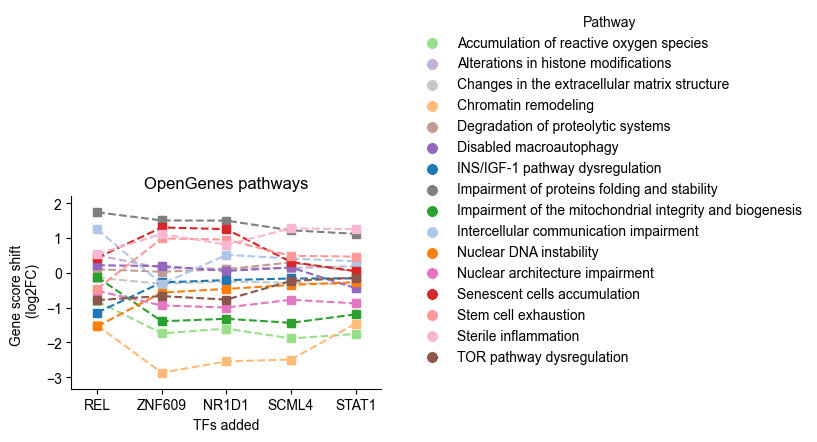

In [95]:
from ciim.src.utils.util import get_opengenes_sets
terms =  list(get_opengenes_sets().keys())
mean_scores_s = mean_scores[mean_scores['pathway'].isin(terms)]
plot_pathway_score_shift(mean_scores_s)
plt.title(f'OpenGenes pathways', fontsize=12, weight='bold')

In [ ]:
aaa 

NameError: name 'aaa' is not defined

# Single aging TF perturbation

In [ ]:
datasets = datasets_all[:2]
if True: # run
    # --- Single TF Perturbation ---
    stats_aging = retrieve_sig_stats(type='bulk', race='both', filter_inconsistent=True)

    perturb_rr_dict = {}
    for cell_type in cell_types:
        tfs = stats_aging[stats_aging['cell_type'] == cell_type]['tf'].unique()
        
        par['perturbation_mode'] = 'overexpression'
        if 'tfs' in par:
            del par['tfs']
        perturb_rr = wrapper_in_silico_single_perturbation(tfs=tfs, par=par, n_jobs=n_jobs, cell_types=[cell_type], datasets=datasets)
        perturb_rr_dict[cell_type] = perturb_rr

perturb_rr_mean_store = []
for cell_type, perturb_rr in perturb_rr_dict.items():
    perturb_rr_mean = perturb_rr.groupby(['cell_type','dataset', 'tf'])['age_shift'].apply(lambda x: x['age_shift'].mean()).reset_index(name='mean_diff')
    perturb_rr_mean_store.append(perturb_rr_mean)
perturb_rr_mean = pd.concat(perturb_rr_mean_store)
stats_aging = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])[['tf', 'cell_type', 'trend']]
perturb_rr_mean = perturb_rr_mean.merge(stats_aging, on=['tf', 'cell_type'], how='left')
perturb_rr_mean.to_csv(f"{save_dir}/perturbation/single_aging_tf_age_shift_mean.csv", index=False)

score_shift_summary = summarize_pathway_scores(perturb_rr, cols=['cell_type', 'dataset', 'tf'])
score_shift_summary.to_csv(f"{save_dir}/perturbation/single_aging_tf_pathway_score_shift.csv", index=False)

perturb_rr_mean.head()

,cell_type,dataset,tf,mean_diff,trend
0,CD4T,data1,AHR,0.054157,Increase in aging
1,CD4T,data1,ARHGAP35,-1.831377,Increase in aging
2,CD4T,data1,ARID5B,-1.042753,Increase in aging
3,CD4T,data1,BACH2,-32.296655,Decrease in aging
4,CD4T,data1,BATF,-3.332738,Increase in aging


## Check the normality of age shift

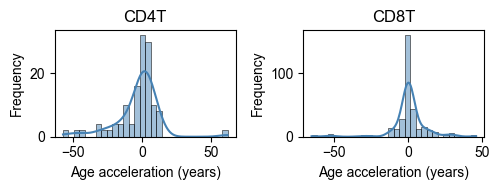

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Unique cell types
cell_types = perturb_rr_mean['cell_type'].unique()
n = len(cell_types)

# Determine subplot grid size
ncols = 5
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.5, nrows * 2))
axes = axes.flatten()  # Flatten in case of 2D axes array

for i, cell_type in enumerate(cell_types):
    df = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    
    ax = axes[i]

    sns.histplot(df['mean_diff'], bins=30, kde=True, color='steelblue', ax=ax)
    ax.set_title(cell_type)
    ax.set_xlabel('Age acceleration (years)')
    ax.set_ylabel('Frequency')

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

## Significance of age acceleration per TF

In [51]:
# - normalized significance
from scipy.stats import norm

perturb_rr_mean['z_score'] = perturb_rr_mean.groupby('cell_type')['mean_diff'].transform(
    lambda x: (x - x.mean()) / x.std()
)

In [52]:

perturb_rr_mean.head()

,cell_type,dataset,tf,mean_diff,z_score,trend
0,CD4T,data1,AHR,0.054157,0.192748,Increase in aging
1,CD4T,data1,ARHGAP35,-1.831377,0.076405,Increase in aging
2,CD4T,data1,ARID5B,-1.042753,0.125066,Increase in aging
3,CD4T,data1,BACH2,-32.296655,-1.803392,Decrease in aging
4,CD4T,data1,BATF,-3.332738,-0.016233,Increase in aging


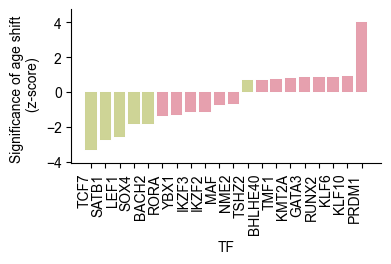

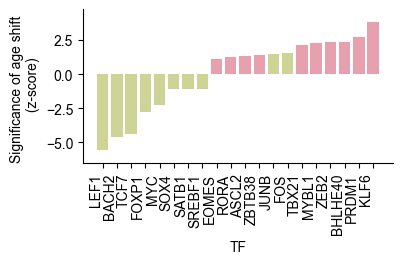

In [ ]:
from ciim.src.insilico_perturbation.plots import wrapper_plot_age_acceleration_for_tf_perturbation

value_col= 'z_score' #'mean_diff' #'z_score'#'signed_neg_log10_pval'
features = None
top_n=20

top_tfs_dict = {}
for cell_type in cell_types:
    perturb_rr_mean_t = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type]

    if False:
        # filter for sig aging TFs
        aging_stats = retrieve_sig_stats(type='bulk')
        aging_tfs = aging_stats[aging_stats['cell_type'] == cell_type]['tf'].unique()
        perturb_rr_mean_t = perturb_rr_mean_t[perturb_rr_mean_t['tf'].isin(aging_tfs)]
    
    aa, top_tfs = wrapper_plot_age_acceleration_for_tf_perturbation(perturb_rr_mean_t, 
                                            value_col=value_col, 
                                            top_n=top_n,
                                            figsize=(4, 2))
    # plt.legend().remove()
    top_tfs_dict[cell_type] = top_tfs
    plt.title(f"", pad=15, weight='bold')
    plt.savefig(f"{plots_dir}/aging_tf_perturbation_{cell_type}.png", bbox_inches='tight', dpi=300, transparent=True)

## Aging trends: verification

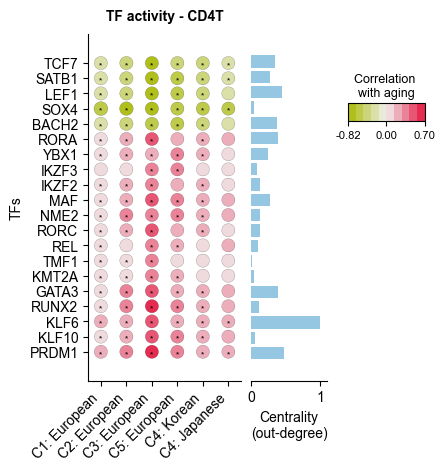

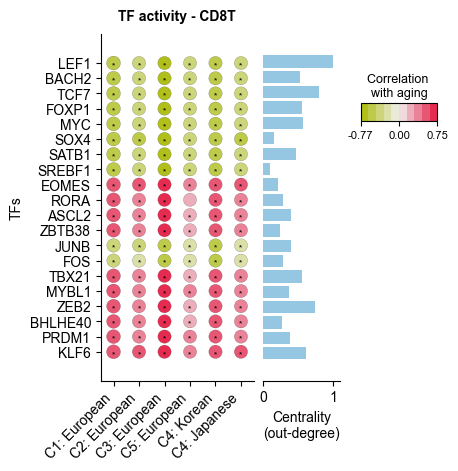

In [374]:
for cell_type in cell_types:
    top_tfs = top_tfs_dict[cell_type]
    df_cell = perturb_rr_mean[perturb_rr_mean['cell_type'] == cell_type].copy()
    

    # median_abs = df_cell.groupby('tf')[value_col].apply(lambda x: x.abs().median())

    # Keep only top TFs
    df_cell = df_cell[df_cell['tf'].isin(top_tfs)].copy()

    # Sort TFs by signed mean_diff for plotting
    tf_order = df_cell.groupby('tf')[value_col].mean().sort_values().index
    df_cell['tf'] = pd.Categorical(df_cell['tf'], categories=tf_order, ordered=True)
    df_cell['tf'].cat.categories

    features = df_cell['tf'].cat.categories
    from ciim.src.tf_activity.plots import plot_features_vs_datasets
    bb = plot_features_vs_datasets(cell_type=cell_type, type='bulk', datasets=datasets_all, features=features, feature_type='tf_activity', 
                                sizes=(90, 100), width=4,
                                margins_ax1={'x': 0.1, 'y': 0.1}, margins_ax2={'x': 0.1, 'y': 0.07})
    # plt.suptitle(f"", fontsize=12, weight='bold')
    plt.savefig(f"{plots_dir}/{cell_type}_tf_activity.png", bbox_inches='tight', dpi=300, transparent=True)

## Consistency of the age shift with aging TFs: verification 

In [ ]:
# Import dependencies
from ciim.src.tf_activity.helper import retrieve_sig_stats

# Get the sign of slope for perturbation analysis
# perturb_rr_sig = perturb_rr[perturb_rr['signed_neg_log10_pval'].abs()>1.4]
perturb_slope_sign = (
    perturb_rr_mean.groupby(['cell_type', 'tf'])['mean_diff']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'mean_diff': 'slope'})
)


# Get the sign of slope for aging TFs (reference)
stats = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['tf', 'cell_type'])
aging_slope_sign = (
    stats.groupby(['cell_type', 'tf'])['slope']
    .median()
    .apply(np.sign)
    .reset_index()
    .rename(columns={'slope': 'slope'})
)

# Cell type-specific overlap
overlap_results = []

for cell_type in cell_types:
    # Subset aging (reference) and perturbation data
    aging_t = aging_slope_sign[aging_slope_sign['cell_type'] == cell_type]
    perturb_t = perturb_slope_sign[perturb_slope_sign['cell_type'] == cell_type]
    # Merge on TFs that are found in both
    merged = aging_t.merge(perturb_t, on='tf', suffixes=('_aging', '_perturb'), how='inner')

    if merged.empty:
        continue

    # Count matches with respect to aging slope
    matched = (merged['slope_aging'] == merged['slope_perturb']).sum()
    total = merged.shape[0]
    fraction_matched = matched / total

    overlap_results.append({
        'cell_type': cell_type,
        'n_ref_tfs': len(aging_t),
        'n_overlap_tfs': total,
        'n_matched': matched,
        'percent_matched': 100*fraction_matched
    })


overlap_df = pd.DataFrame(overlap_results)
overlap_df

,cell_type,n_ref_tfs,n_overlap_tfs,n_matched,percent_matched
0,CD4T,67,67,39,58.208955
1,CD8T,163,163,133,81.595092


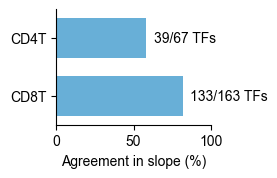

In [413]:
import matplotlib.pyplot as plt
import seaborn as sns
figsize=(2, 1.5)
def plot_tf_slope_overlap(overlap_df):
    fig, ax = plt.subplots(figsize=figsize)

    # Plot the bars
    barplot = sns.barplot(
        data=overlap_df,
        x='percent_matched',
        y='cell_type',
        ax=ax,
        width=0.7,
        # palette='viridis'
        color=colors_blind[1],
    )

    # Add text labels directly on the bars
    for bar, (_, row) in zip(barplot.patches, overlap_df.iterrows()):
        width = bar.get_width()
        y_center = bar.get_y() + bar.get_height() / 2
        label = f"{int(row['n_matched'])}/{int(row['n_overlap_tfs'])} TFs"
        ax.text(width + 5, y_center, label, va='center', ha='left', fontsize=10, color='black')

    ax.set_xlim(0, 100)
    ax.set_xlabel('Agreement in slope (%)')
    ax.set_ylabel('')
    sns.despine()
    return fig

# Usage
aa = plot_tf_slope_overlap(overlap_df[overlap_df['cell_type'].isin(['CD4T', 'CD8T', 'MONO', 'NK'])])
plt.savefig(f"{plots_dir}/aging_tf_slope_overlap.png", bbox_inches='tight', dpi=300, transparent=True)

## Pathway scores

In [74]:
cell_type = 'CD8T'
ordered_top_tfs = top_tfs_dict[cell_type]
perturb_rr = perturb_rr_dict[cell_type].copy()
perturb_rr = perturb_rr[perturb_rr['tf'].isin(ordered_top_tfs)].copy()
score_shift_summary = summarize_pathway_scores(perturb_rr, cols=['cell_type', 'dataset', 'tf'])
df_summary_opengenes = score_shift_summary[score_shift_summary['pathway'].isin(opengenes_pathways)]
df_summary_opengenes[gene_score_shift_col] = df_summary_opengenes[gene_score_shift_col].abs()
pivot_df = df_summary_opengenes.pivot_table(index='pathway', columns='tf', values=gene_score_shift_col)
pivot_df = pivot_df[ordered_top_tfs]  # reorder columns based on ordered_top_tfs

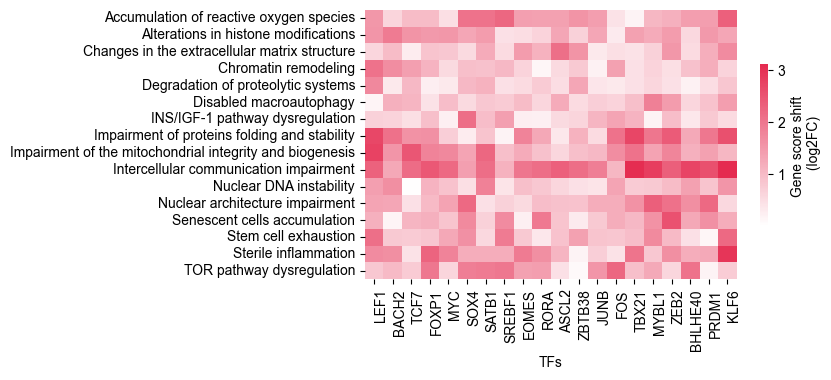

In [97]:
fig, ax1 = plt.subplots(1, 1, figsize=(6, max(3.5, len(pivot_df) * 0.18)))
heatplot_perturbation_effect(pivot_df, ax1)
ax1.set_xlabel('TFs')
bb = ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')

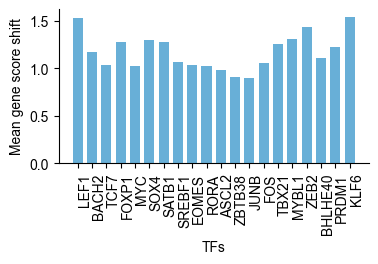

In [ ]:
mean_pivot_df = pivot_df.mean(axis=0).reset_index(name='mean_value')
fig, ax = plt.subplots(figsize=(4, 2))
barplot = sns.barplot(
        data=mean_pivot_df,
        y='mean_value',
        x='tf',
        ax=ax,
        width=0.7,
        # palette='viridis'
        color=colors_blind[1],
    )
ax.spines[['top', 'right']].set_visible(False)  # Hide top and right spines
ax.set_ylabel('Mean gene score shift')
ax.set_xlabel('TFs')
ax.margins(x=0.05, y=0.05)
bb = ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right', rotation_mode='anchor')

# Combinatorial aging TFs perturbation

Text(0.5, 1.25, 'Combinatorial perturbation of aging TFs: CD4T')

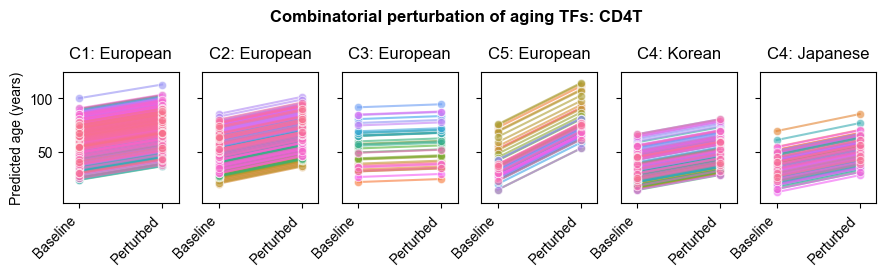

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_natural_aging['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_natural_aging[(df_natural_aging['cell_type'] == cell_type) & (df_natural_aging['dataset'] == dataset)].copy()
    df = df['age_shift'].copy()

    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD4T' 'CD8T']


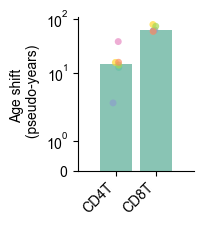

In [427]:
df_mean_aging = df_natural_aging.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_aging['dataset'] = pd.Categorical(df_mean_aging['dataset'], categories=datasets_all, ordered=True)
fig = plot_age_acceleration(df_mean_aging[df_mean_aging['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], 
                            log_y=True, figsize=(1.5, 2),
                            margins=(0.3, 0.4))
plt.legend().remove()
# plt.title('Combinatorial perturbation of aging TFs\n (natural aging mode)', pad=15)

# Combinatorial perturbation of SLE associated aging TFs

In [362]:
# --- SLE TF Perturbation ---
def retrieve_sig_stats_disease(dataset='', feature_type='tf_activity', test_type='unpaired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05) & (stats_drug['age_group'] == 'Both age groups')].copy()

def get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_disease_sig = stats_disease_sig[['cell_type', 'tf', 'slope_condition']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_disease_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]


In [ ]:
def run_sle_tf_perturbation():
    print('Running SLE TF perturbation...')
    dataset = 'SLE_European'
    stats_disease_sig = retrieve_sig_stats_disease(dataset=dataset)
    if True: # overlap with aging TFs
        slope_sle = get_overlapping_tf_slopes_in_disease_and_aging(stats_disease_sig)
    else: # SLE TFs
        slope_sle = stats_disease_sig[['tf','cell_type','slope_condition']].set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type']]
        print(slope_sle.groupby('cell_type').size())
    slope_sle['slope'] = np.sign(slope_sle['slope']) 
    par_sle = {
        'simulation_iteration': simulation_iteration,
        'n_donors': n_donors,
        'data_type': data_type,
        'version': version,
        'reg_type': reg_type,
        'feature_type': 'gene_expression',
        'perturbation_mode': None,
        'slope_df': slope_sle,
    }
    df_sle = wrapper_in_silico_perturbation(par_sle, n_jobs=1, cell_types=cell_types, datasets=datasets_all)
    return df_sle
df_sle = run_sle_tf_perturbation()

Running SLE TF perturbation...
Processing: CD4T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for NOTCH SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for PANCREAS BETA CELLS: Error calculating gene scores: Privided genes list is empty..

Text(0.5, 1.25, 'Combinatorial perturbation of SLE-affected aging TFs: CD4T')

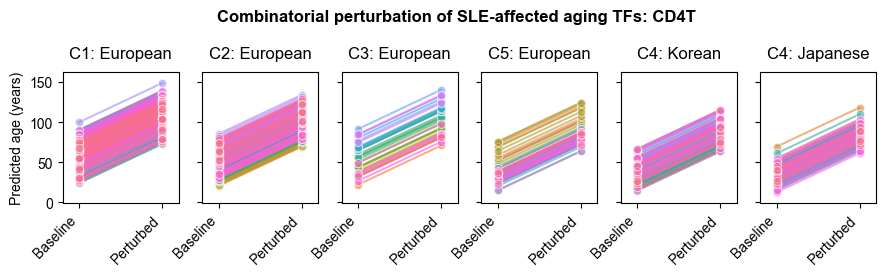

In [ ]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
cell_type = cell_types[0]
datasets = df_sle['dataset'].unique()
n_datasets = len(datasets)
fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
for i, dataset in enumerate(datasets):
    ax = axes[i] if n_datasets > 1 else axes
    df = df_sle[(df_sle['cell_type'] == cell_type) & (df_sle['dataset'] == dataset)].copy()
    df = df['age_shift'].reset_index()
    # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    ax.set_title(f"{surrogate_names[dataset]}", pad=10)

plt.suptitle(f"Combinatorial perturbation of SLE-affected aging TFs: {cell_type}", y=1.25, fontsize=12, fontweight='bold')

['CD4T' 'CD8T']


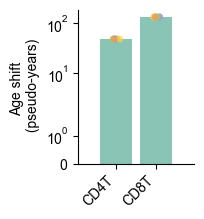

In [ ]:
df_mean_sle = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_sle['dataset'] = pd.Categorical(df_mean_sle['dataset'], categories=datasets_all, ordered=True)
fig = plot_age_acceleration(df_mean_sle[df_mean_sle['cell_type'].isin(['CD4T', 'CD8T', 'NK' ,'MONO'])], log_y=True,
                               figsize=(1.5, 2),
                            margins=(0.3, 0.4), color=colors_blind[2])
plt.legend().remove()
plt.savefig(f'{plots_dir}/sle_tf_perturbation.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)

# Drug perturbation

In [367]:
# --- Drug Perturbation ---
def retrieve_sig_stats_drug(feature_type='tf_activity', dataset='CXCL9', test_type='paired', type='bulk'):
    stats_drug = pd.read_csv(f'{save_dir}/stats/stats_{dataset}_{type}_{feature_type}_{test_type}.csv', index_col=0)
    return stats_drug[(stats_drug['p_value_adj'] < 0.05)].copy()

def get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig):
    stats_aging_sig = retrieve_sig_stats(type='bulk').drop_duplicates(subset=['cell_type', 'tf'])[['cell_type', 'tf']]
    stats_drug_sig = stats_drug_sig[['cell_type', 'tf', 'slope_condition', 'comparision']].drop_duplicates()
    stats_both = stats_aging_sig.merge(stats_drug_sig, on=['cell_type', 'tf'], how='inner')
    return stats_both.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]

In [383]:
from ciim.src.insilico_perturbation.helper import wrapper_in_silico_perturbation
def run_perturbation_tf_perturbation():
    print('Running drug perturbation TF perturbation...')
    stats_drug_sig = retrieve_sig_stats_drug(dataset='CXCL9')
    if True: # overlapping TFs
        df_slope = get_overlapping_tf_slopes_in_drug_and_aging(stats_drug_sig)
    else:
        df_slope = stats_drug_sig.set_index('tf').rename(columns={'slope_condition': 'slope'})[['slope', 'cell_type', 'comparision']]
    print(df_slope.groupby(['cell_type', 'comparision']).size())
    df_slope['slope'] = np.sign(df_slope['slope'])
    df_slope.head()
    df_store = []
    # for comparision in tqdm(df_slope['comparision'].unique()):
    for comparision in ['LPS (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)']: #['Ruxolitinib (ctr: LPS)']
        df_slope_c = df_slope[df_slope['comparision'] == comparision].copy()

        par['perturbation_mode'] = None
        par['slope_df'] = df_slope_c

        df_all_c = wrapper_in_silico_perturbation(par, 
                                    n_jobs=n_jobs,
                                    cell_types=cell_types,
                                    datasets=datasets_all #['data1', 'data12']# aging_clock_train_datasets, #['data12'] # datasets_all
                                    )
        df_all_c['comparision'] = comparision
        df_store.append(df_all_c)
    df_all = pd.concat(df_store)
    # df_all.to_csv(f"{save_dir}/perturbation/tf_screen_results_drug_perturbation.csv")
    return df_all
df_perturbation_all = run_perturbation_tf_perturbation()

Running drug perturbation TF perturbation...
cell_type  comparision            
CD4T       LPS (ctr: RPMI)            53
CD8T       LPS (ctr: RPMI)            49
           Ruxolitinib (ctr: LPS)     98
MONO       LPS (ctr: RPMI)            35
           Metformin (ctr: LPS)       35
           Ruxolitinib (ctr: LPS)     20
           Ruxolitinib (ctr: RPMI)    31
NK         LPS (ctr: RPMI)            20
dtype: int64
Processing: CD4T - data1 (None | multi)
Error calculating gene scores for ANGIOGENESIS: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for APICAL SURFACE: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for HEDGEHOG SIGNALING: Error calculating gene scores: Privided genes list is empty.. Ensure that the genes are present in the dataset.
Error calculating gene scores for MYC TARGETS V2: E

In [384]:
from ciim.src.insilico_perturbation.plots import plot_age_acceleration_donors
if False: # donor level plots
    from ciim.src.insilico_perturbation.helper import perform_stat_test
    cell_type = cell_types[0]
    for comparision in df_perturbation_all['comparision'].unique():
        print(comparision)
        datasets = df_perturbation_all['dataset'].unique()
        n_datasets = len(datasets)
        fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
        for i, dataset in enumerate(datasets):
            ax = axes[i] if n_datasets > 1 else axes
            df = df_perturbation_all[(df_perturbation_all['cell_type'] == cell_type) & (df_perturbation_all['dataset'] == dataset)  & (df_perturbation_all['comparision'] == comparision)].copy()
            df = df['age_shift'].reset_index()
            # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
            # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
            plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
            ax.set_title(f"{surrogate_names[dataset]}", pad=10)

        plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')
    # comparision = 'Ruxolitinib (ctr: LPS)'
    # datasets = df_all['dataset'].unique()
    # n_datasets = len(datasets)
    # fig, axes = plt.subplots(1, n_datasets, figsize=(1.5 * n_datasets + 1.5, 1.7), sharey=True)
    # for i, dataset in enumerate(datasets):
    #     ax = axes[i] if n_datasets > 1 else axes
    #     df = df_all[(df_all['cell_type'] == cell_type) & (df_all['dataset'] == dataset)  & (df_all['comparision'] == comparision)].copy()

    #     # df_pivot = obs_all[(obs_all['cell_type'] == 'CD8T') & (obs_all['dataset'] == dataset)].copy()
    #     # p_value, slope = perform_stat_test(perturb_rr, ctr=ctr, treatment=treatment)
    #     plot_age_acceleration_donors(df, ctr='Baseline', treatment='Perturbed', ax=ax)
    #     ax.set_title(f"{surrogate_names[dataset]}", pad=10)

    # plt.suptitle(f"Treatment: {comparision}", y=1.25, fontsize=12, fontweight='bold')

['CD4T']
['CD8T']


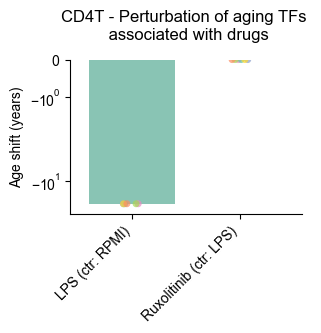

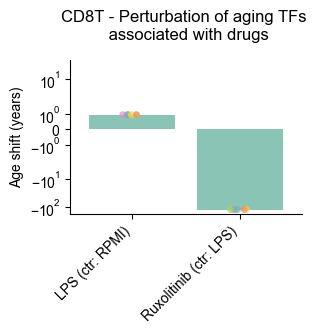

In [ ]:
for cell_type in df_perturbation_all['cell_type'].unique():
    df = df_perturbation_all[df_perturbation_all['cell_type'] == cell_type].copy()
    # df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median().reset_index(name='mean_diff')
    df_mean = df.groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    df_mean['dataset'] = pd.Categorical(df_mean['dataset'], categories=datasets_all, ordered=True)
    plot_age_acceleration(df_mean, x_col='comparision', log_y=True, figsize=(3, 2),
                            margins=(0.1, 0.4))
    plt.legend().remove()
    plt.title(f"{cell_type} - Perturbation of aging TFs \n associated with drugs", pad=15)

# Summary plot of all combinatorial perturbations

In [434]:
df_mean_ruxo = df_perturbation_all[(df_perturbation_all['comparision'] == 'Ruxolitinib (ctr: LPS)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
    

['CD4T']
['CD8T']


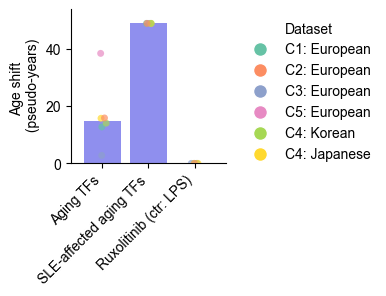

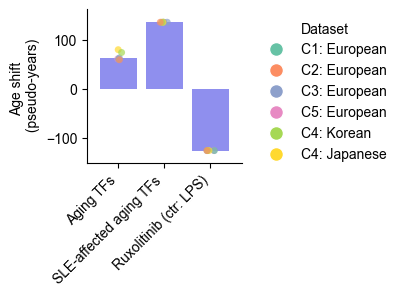

In [435]:
for cell_type in cell_types:
    df_mean_ruxo_c = df_mean_ruxo[(df_mean_ruxo['cell_type'] == cell_type)]
    df_mean_sle_c = df_mean_sle[(df_mean_sle['cell_type'] == cell_type)].copy()
    df_mean_aging_c = df_mean_aging[(df_mean_aging['cell_type'] == cell_type)].copy()

    df_mean_ruxo_c['experiment'] = 'Ruxolitinib (ctr: LPS)'
    df_mean_sle_c['experiment'] = 'SLE-affected aging TFs'
    df_mean_aging_c['experiment'] = 'Aging TFs'

    df_mean = pd.concat([df_mean_aging_c, df_mean_sle_c, df_mean_ruxo_c], ignore_index=True)

    # Normalize by aging TFs
    # df_aging_vals = df_mean[df_mean['experiment'] == 'Aging TFs'][['dataset', 'age_shift']].rename(
    #     columns={'age_shift': 'age_shift_aging'}
    # )

    # df_mean = df_mean.merge(df_aging_vals, on='dataset', how='left')
    # df_mean['age_shift'] = df_mean['age_shift'] / df_mean['age_shift_aging']

    df_mean['dataset'] = pd.Categorical(df_mean['dataset'], categories=datasets_all, ordered=True)

    plot_age_acceleration(df_mean, x_col='experiment', log_y=False, figsize=(2, 2),
                                margins=(0.1, .1))
    plt.savefig(f"{plots_dir}/aging_tf_perturbation_summary_{cell_type}.png", bbox_inches='tight', dpi=300, transparent=True)

In [ ]:
df_perturbation_all['comparision'].unique()

array(['LPS (ctr: RPMI)', 'Ruxolitinib (ctr: LPS)'], dtype=object)

['CD4T' 'CD8T']
['CD4T' 'CD8T']
['CD4T' 'CD8T']
['CD4T' 'CD8T']


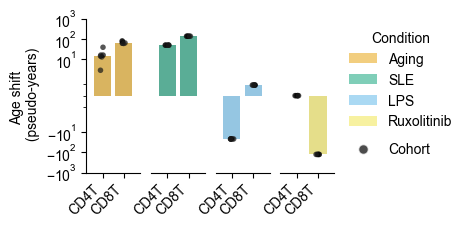

In [562]:
alpha=0.7
color_dataset='black'

df_mean_aging = df_natural_aging.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_sle = df_sle.groupby(['cell_type', 'dataset'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_ruxo = df_perturbation_all[(df_perturbation_all['comparision'] == 'Ruxolitinib (ctr: LPS)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()
df_mean_lps = df_perturbation_all[(df_perturbation_all['comparision'] == 'LPS (ctr: RPMI)')].groupby(['cell_type', 'dataset', 'comparision'])['age_shift'].median()['age_shift']['age_shift'].reset_index()


experiments = ['Aging', 'SLE', 'LPS', 'Ruxolitinib']
dfs = [df_mean_aging, df_mean_sle, df_mean_lps, df_mean_ruxo]
colors = [colors_blind[0], colors_blind[2], colors_blind[1], colors_blind[3]]

# df_combined = pd.concat(dfs, ignore_index=True)
# min_age_shift = df_combined['age_shift'].min()
# max_age_shift = df_combined['age_shift'].max()
# lim = [min_age_shift-20, max_age_shift+20]

fig, axes = plt.subplots(1, len(experiments), figsize=(.8 * len(experiments), 2), sharey=False)


def plot_age_shift(df_all, 
                        x_col='cell_type', 
                        figsize=(3, 3),
                        color='blue',
                        ax=None):
    # If a specific order is given, enforce it
    order = df_all[x_col].unique()
    print(df_all['cell_type'].unique())
    # Calculate median per category
    df_median = df_all.groupby(x_col)['age_shift'].median().reset_index()
    # Plotting
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    df_all['dataset'] = df_all['dataset'].apply(lambda name: surrogate_names.get(name, name))
    sns.stripplot(ax=ax, data=df_all, y='age_shift', x=x_col, hue='dataset',
                  color=color_dataset, alpha=alpha, order=order, s=4)

    sns.barplot(ax=ax, data=df_median, y='age_shift', x=x_col, alpha=alpha, color=color, order=order)
    
    # Axes and labels
    ax.set_ylabel("Age shift \n (pseudo-years)")
    ax.set_xlabel("")
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

    
for experiment, df in zip(experiments, dfs):
    
    i = experiments.index(experiment)
    ax = axes[i]
    color = colors[i]
    df['dataset'] = pd.Categorical(df['dataset'], categories=datasets_all, ordered=True)

    plot_age_shift(df, color=color, ax=ax)
    # ax.get_legend().remove()
    # ax.set_ylim(lim)
    
    ax.get_legend().remove()

    # - log x axis
    ax.set_yscale('symlog')
    ax.set_yticks([-1000, -100, -10, 10, 100, 1000])
    # ax.set_yticklabels(['-100', '-10', '10', '100'])
    ax.margins(x=0.2)
    if i != 0:
        ax.set_ylabel('')
        ax.set_yticks([])  # Ensure no ticks are shown
        ax.set_yticklabels([])  # Also clear any existing labels
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.spines['left'].set_visible(False)
         
def plot_legends(ax):
    import matplotlib.patches as mpatches
    from matplotlib.lines import Line2D
    legend1_handles = [
        Line2D([0], [0], marker='o', color='w',
            markerfacecolor=color_dataset, alpha=alpha,
            markersize=7, label='Cohort', linestyle='None')
    ]
    legend1 = ax.legend(handles=legend1_handles, title='',
                        bbox_to_anchor=(1.05, 0.15), loc='center left', frameon=False)
    ax.add_artist(legend1)
    legend2_handles = [
        Patch(facecolor=colors[i], edgecolor=None, label=ds, alpha=0.5)
        for i, ds in enumerate(experiments)
    ]
    ax.legend(handles=legend2_handles, title='Condition',
            bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)
plot_legends(ax)
plt.savefig(f'{plots_dir}/multi_tf_perturbation.png', bbox_inches='tight', dpi=300, transparent=True)
# plt.title(f'Perturbation of aging TFs \n associated with SLE disease', pad=15)